In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n=1000

df = pd.DataFrame({
    'MedInc': np.random.uniform(1,10,n),
    'HouseAge':np.random.uniform(1,52,n),
    'AveRooms':np.random.uniform(3,10,n),
    'AveBedrms':np.random.uniform(1,3,n),
    'Population':np.random.uniform(100,3000,n),
    'AveOccup': np.random.uniform(1,5,n),
    'Latitude':np.random.uniform(32,42,n),
    'Longtitude': np.random.uniform(-124,-114,n)

})

df['Price']= (df['MedInc']*0.5 +
              df['HouseAge']*0.3 -
              df['AveOccup']*0.1 +
              np.random.normal(0,0.5,n))


In [3]:
print(df.shape)  # (1000, 9) — 1000 rows, 9 columns
df.head()        # shows first 5 rows

(1000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longtitude,Price
0,4.370861,10.441779,4.831940,2.345406,1758.788047,2.574542,38.482570,-123.612005,5.539918
1,9.556429,28.636948,4.728852,2.593363,2435.753755,2.893743,33.723864,-122.132275,13.643768
2,7.587945,45.520238,9.343782,1.500936,2304.466696,4.418190,40.723946,-115.687542,16.034554
3,6.387926,38.343469,4.746823,2.249748,546.309724,2.360018,38.131162,-116.332316,14.950231
4,2.404168,42.134619,4.903648,2.143492,532.823462,4.478599,33.572039,-120.493573,12.989345


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X = df.drop('Price', axis = 1)
y= df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(800, 8)
(200, 8)
(800,)
(200,)


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained!
Coefficients: [ 4.90540113e-01  3.01744341e-01 -7.04415590e-05 -1.05702508e-02
 -1.64584911e-05 -1.19514562e-01  4.02656402e-03 -1.68916257e-03]
Intercept: -0.24915704214035017


In [7]:
y_pred = model.predict(X_test)

print("First five actual prices",y_test.values[:5])
print("First five predicted prices",y_pred[:5])


First five actual prices [16.75850751  6.85468568 15.31739791 11.66732963  6.72063652]
First five predicted prices [16.49751845  7.18632244 15.04425731 11.46310973  6.5390915 ]


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error :", mse)
print("R-Squared score :", r2)
print("Mean Absolute Error :", mae)

Mean Squared Error : 0.3019463663789241
R-Squared score : 0.9865692518729803
Mean Absolute Error : 0.4403836614140043


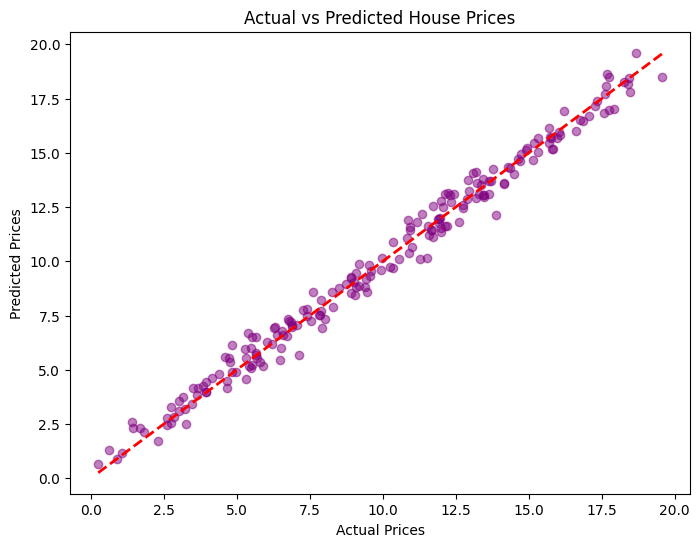

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha = 0.5, color='purple')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()
